[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/duoan/TorchCode/blob/master/templates/20_weight_init.ipynb)

# 🟢 Easy: Kaiming Initialization

Implement **Kaiming (He) normal initialization** for weight tensors.

$$W \sim \mathcal{N}(0, \text{std}^2) \quad \text{where} \quad \text{std} = \sqrt{\frac{2}{\text{fan\_in}}}$$

### Signature
```python
def kaiming_init(weight: Tensor) -> Tensor:
    # Initialize weight in-place with Kaiming normal
    # fan_in = weight.shape[1]
    # Returns the weight tensor
```

In [1]:
# Install torch-judge in Colab (no-op in JupyterLab/Docker)
try:
    import google.colab
    get_ipython().run_line_magic('pip', 'install -q torch-judge')
except ImportError:
    pass


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 1.5 MB/s eta 0:00:00


In [2]:
import torch
import math

## Kaiming Initialization
딥러닝 모델을 처음 만들면 weight 값들을 무작위로 정해줘야 함. 근데 이 랜덤한 숫자들이 너무 크거나 너무 작으면 문제가 생김.

너무 큼 -> 숫자가 explode함
너무 작음 -> 신호가 점점 약해지다가 사라져버림 (vanishing)

ReLU의 경우 잘 죽음.
-> 그래서 ReLU를 쓸 경우 이런 방식으로 초기화하자. 라고 제안한게 카이밍 초기화

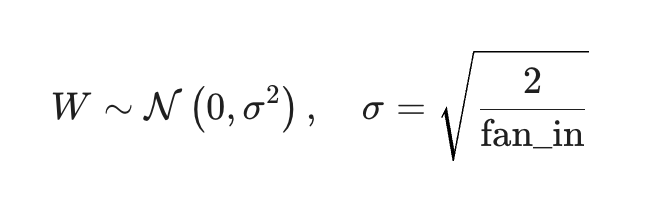

In [3]:
# ✏️ YOUR IMPLEMENTATION HERE

def kaiming_init(weight):
    # fill with normal(0, sqrt(2/fan_in))

    """
    fan_in은 이 레이어로 들어오는 입력 수
    weight은 (출력 수, 입력 수)로 주어짐
    보통은 2D 텐서니까, 입력수를 쓰려면 1번 인덱스를 가져감!
    만약에 1D 텐서라면 0번 인덱스 쓰면 됨

    """
    fan_in = weight.shape[1] if weight.dim() >= 2 else weight.shape[0]

    # kaiming 공식
    # 왜 2이냐? ReLU는 음수를 0으로 만들어서 절반을 날려버림.
    # 그 손실을 보충하려고 2를 곱해주는 것!
    # fan_in이 클수록 std가 작아짐.
    # -> 입력이 많을수록 가중치를 작게 초기화함
    std = math.sqrt(2.0 / fan_in)

    # gradient 계산할 필요 없음
    with torch.no_grad():
      # normal_(평균, 표준편차)
      # 뒤에 _ 가 붙으면 PyTorch에서 원본을 직접 수정한다는 뜻!
      # weight를 새로 만드는게 아니라, 기존 텐서 자체를 바꿔줌
      # 평균 0, 표준편차 std인 정규분포로 weight를 랜덤하게 채움
      weight.normal_(0, std)

    # 수정된 weight만 반환
    return weight

In [ ]:
def kaiming_init(weight):
  fan_in = weight.shape[1] if weight.dim() >= 2 else weight.shape[0]
  std = math.sqrt(2.0 / fan_in)

  with torch.no_grad():
    weight.normal_(0, std)

  return weight

In [4]:
# 🧪 Debug
import math
w = torch.empty(256, 512)
kaiming_init(w)
print(f'Mean: {w.mean():.4f} (expect ~0)')
print(f'Std:  {w.std():.4f} (expect {math.sqrt(2/512):.4f})')

Mean: -0.0003 (expect ~0)
Std:  0.0624 (expect 0.0625)


In [5]:
# ✅ SUBMIT
from torch_judge import check
check('weight_init')


🧪 Testing: Kaiming Initialization (Easy)
──────────────────────────────────────────────────
  ✅ [1/4] Mean approximately 0 (10.3ms)
  ✅ [2/4] Std matches sqrt(2/fan_in) (5.7ms)
  ✅ [3/4] Returns same tensor (in-place) (0.4ms)
  ✅ [4/4] Smaller fan_in gives larger std (0.6ms)
──────────────────────────────────────────────────
  🎉 All 4 tests passed! (16.9ms total)
  Progress saved. Run status() to see your dashboard.

